## Analistes de Màrqueting i Comunicació: 
Quina relació hi ha entre el nombre de contactes realitzats durant aquesta campanya i la taxa d'èxit, i com podem optimitzar la freqüència de contacte per maximitzar els resultats de les nostres campanyes de màrqueting? 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Ruta del archivo CSV
ruta_archivo = r"C:\Users\marya\Desktop\Proyecto_Simulación\ProjecteData\Equip_18\Data\dataset_271025.csv"

# Cargar el archivo CSV (separado por comas)
df_BANK_marketing = pd.read_csv(ruta_archivo, sep=';')

In [2]:
Total_contactos = df_BANK_marketing['campaign'].sum()
Total_contactos

np.int64(27999)

In [3]:
Contactos_finales_exitosos=(df_BANK_marketing['deposit'] == 'yes').sum()
Contactos_finales_exitosos



np.int64(5289)

In [4]:
Llamadas_efectivas = df_BANK_marketing.loc[df_BANK_marketing['deposit'] == 'yes', 'campaign'].sum()
Llamadas_efectivas

np.int64(11324)

In [5]:

Tasa_exito_global = (Contactos_finales_exitosos/ Total_contactos) * 100
Tasa_exito_global


np.float64(18.88996035572699)

In [6]:
Tasa_exito_total = (Llamadas_efectivas/Total_contactos)*100
Tasa_exito_total

np.float64(40.444301582199365)

In [7]:
Num_clientes_yes = (df_BANK_marketing['deposit'] == 'yes').sum()
Num_clientes_yes


np.int64(5289)

In [8]:
Numero_promedio_llamadasXcliente_convertido = Llamadas_efectivas/ Num_clientes_yes
Numero_promedio_llamadasXcliente_convertido

np.float64(2.1410474569861977)

In [ ]:
Agrupación_yes = (
    df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']
    .groupby('campaign')
    .size()  # cuenta cuantos yes hay en cada número de llamadas
    .reset_index(name='n_contrataciones')
    .sort_values('campaign')
)


In [ ]:
df_yes = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes'].copy()

Agrupación_yes = (
    df_yes.groupby('campaign')
    .size()
    .reset_index(name='n_contrataciones')
    .sort_values('campaign')
)


total_llamadas_efectivas = df_yes['campaign'].sum()


Agrupación_yes['tasa_efectividad'] = (
    Agrupación_yes['n_contrataciones'] / total_llamadas_efectivas
)

print(Agrupación_yes)





    campaign  n_contrataciones  tasa_efectividad
0          1              2561          0.226157
1          2              1401          0.123720
2          3               618          0.054574
3          4               317          0.027994
4          5               139          0.012275
5          6                92          0.008124
6          7                47          0.004150
7          8                32          0.002826
8          9                21          0.001854
9         10                14          0.001236
10        11                16          0.001413
11        12                 4          0.000353
12        13                 6          0.000530
13        14                 4          0.000353
14        15                 4          0.000353
15        16                 2          0.000177
16        17                 6          0.000530
17        20                 1          0.000088
18        21                 1          0.000088
19        24        

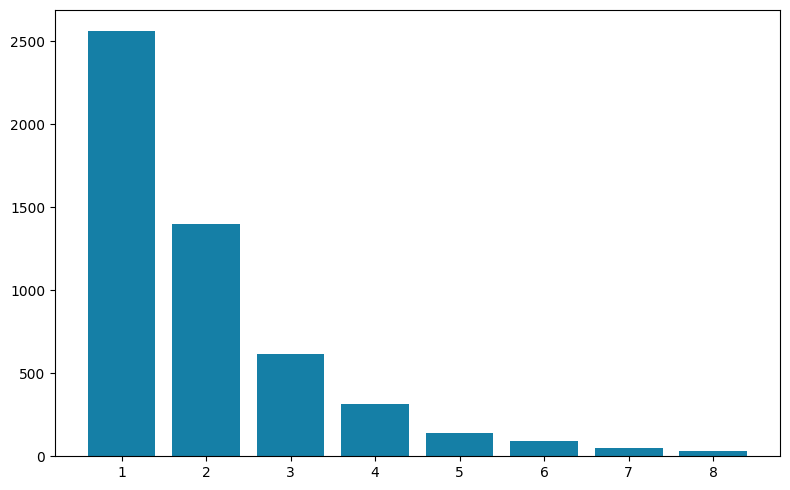

In [ ]:
colores = ["#042748", "#157fa6", "#25405f", "#4a7dba", "#157fa6"]


df_plot = Agrupación_yes[Agrupación_yes['campaign'] <= 8]


plt.figure(figsize=(8,5))
plt.bar(
    df_plot['campaign'].astype(str),
    df_plot['n_contrataciones'],
    color=colores[1]
)

plt.tight_layout()
plt.show()


### EXTENDEMOS LA TABLA PARA VER REALMENTE CUANTAS LLAMADAS FUERON DE NO VS. LAS DE YES

In [ ]:
rows = []

for _, row in df_BANK_marketing.iterrows():
    n_llamadas = row['campaign']
    contratado = (row['deposit'] == 'yes')
    
    for intento in range(1, n_llamadas + 1):
        if contratado and intento == n_llamadas:
            resultado = 'yes'
        else:
            resultado = 'no'
        
        rows.append({
            'id': row['id'],
            'intento': intento,
            'resultado': resultado
        })

df_expandido = pd.DataFrame(rows)
print(df_expandido.tail(20))

          id  intento resultado
27979  11153        3        no
27980  11154        1        no
27981  11155        1        no
27982  11156        1        no
27983  11156        2        no
27984  11157        1        no
27985  11157        2        no
27986  11157        3        no
27987  11157        4        no
27988  11157        5        no
27989  11158        1        no
27990  11159        1        no
27991  11159        2        no
27992  11159        3        no
27993  11159        4        no
27994  11160        1        no
27995  11160        2        no
27996  11161        1        no
27997  11161        2        no
27998  11162        1        no


In [ ]:
Agrupacion_YesNo = (
    df_expandido
    .groupby(['intento', 'resultado'])
    .size()
    .reset_index(name='n_clientes')
    .sort_values('intento')
)
Agrupacion_YesNo.rename(columns={'intento': 'Num llamadas'}, inplace=True)

Agrupacion_YesNo


,Num llamadas,resultado,n_clientes
0,1,no,8601
1,1,yes,2561
2,2,no,4963
3,2,yes,1401
4,3,no,2718
...,...,...,...
80,59,no,1
81,60,no,1
82,61,no,1
83,62,no,1


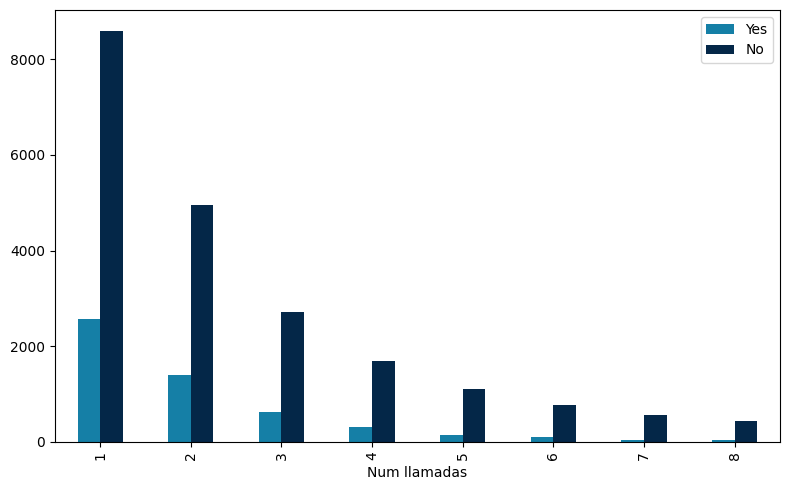

In [ ]:
df_plot = Agrupacion_YesNo[Agrupacion_YesNo['Num llamadas'] <= 8]


df_pivot = df_plot.pivot(index='Num llamadas', columns='resultado', values='n_clientes').fillna(0)


colores = ["#157fa6", "#042748"]  # azul claro = yes, azul oscuro = no


df_pivot[['yes', 'no']].plot(
    kind='bar',
    figsize=(8,5),
    color=colores
)


plt.legend( labels=['Yes', 'No'])

plt.tight_layout()
plt.show()


### Ahora vamos a ver por mes

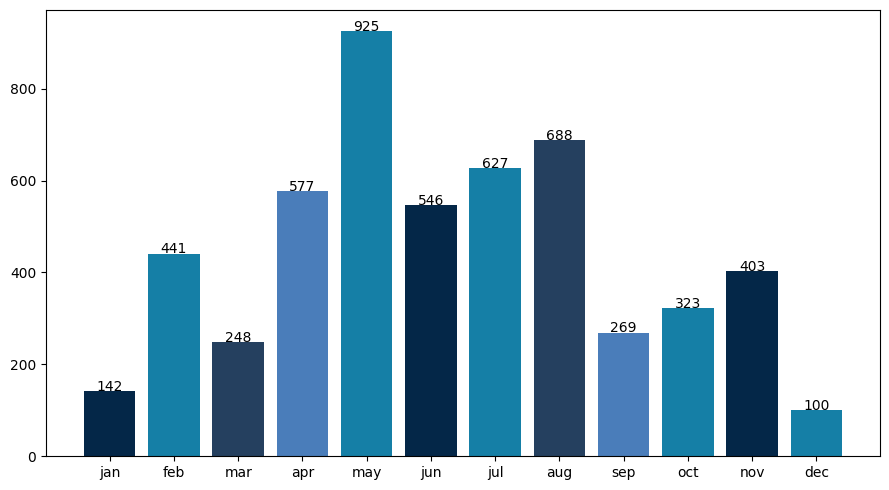

In [ ]:
df_yes = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']


contrataciones_mes = (
    df_yes.groupby('month')
    .size()
    .reset_index(name='n_contrataciones')
)

orden_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

contrataciones_mes['month'] = pd.Categorical(
    contrataciones_mes['month'],
    categories=orden_meses,
    ordered=True
)

contrataciones_mes = contrataciones_mes.sort_values('month')


colores = ["#042748", "#157fa6", "#25405f", "#4a7dba", "#157fa6"]


plt.figure(figsize=(9,5))
plt.bar(
    contrataciones_mes['month'],
    contrataciones_mes['n_contrataciones'],
    color=colores * (len(contrataciones_mes)//len(colores) + 1)  
)




for i, v in enumerate(contrataciones_mes['n_contrataciones']):
    plt.text(i, v + 0.5, str(v), ha='center', fontsize=10)


plt.tight_layout()
plt.show()

#### Este es la tasa para cada mes respecto todas las llamadas que se tuvieron que hacer para conseguir esos YES

In [ ]:
df_yes = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']


contrataciones_mes = (
    df_yes.groupby('month')
    .size()
    .reset_index(name='n_contrataciones')
)


total_llamadas_efectivas = df_yes['campaign'].sum()


contrataciones_mes['tasa_efectividad'] = contrataciones_mes['n_contrataciones'] / total_llamadas_efectivas

orden_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
contrataciones_mes['month'] = pd.Categorical(
    contrataciones_mes['month'],
    categories=orden_meses,
    ordered=True
)
contrataciones_mes = contrataciones_mes.sort_values('month')

print(contrataciones_mes)


   month  n_contrataciones  tasa_efectividad
4    jan               142          0.012540
3    feb               441          0.038944
7    mar               248          0.021900
0    apr               577          0.050954
8    may               925          0.081685
6    jun               546          0.048216
5    jul               627          0.055369
1    aug               688          0.060756
11   sep               269          0.023755
10   oct               323          0.028523
9    nov               403          0.035588
2    dec               100          0.008831


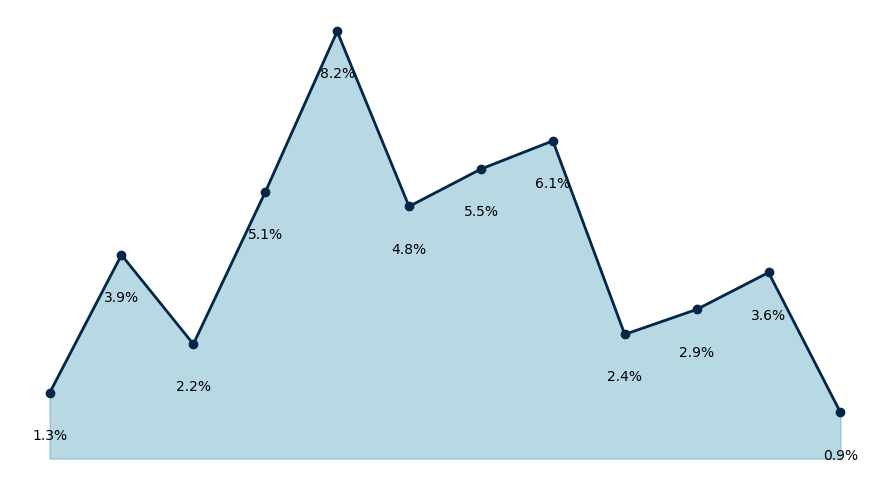

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.fill_between(
    contrataciones_mes['month'],
    contrataciones_mes['tasa_efectividad'],
    color="#157fa6",
    alpha=0.3
)

plt.plot(
    contrataciones_mes['month'],
    contrataciones_mes['tasa_efectividad'],
    marker='o',
    color="#042748",
    linewidth=2
)


for i, v in enumerate(contrataciones_mes['tasa_efectividad']):
    plt.text(i, v - 0.009, f"{v:.1%}", ha='center', fontsize=10, color="black")


ax = plt.gca()
ax.axis('off')

plt.tight_layout()
plt.show()




### Y este la tasa nos da el tanto porcierto de yes total conseguido que representa cada mes

In [ ]:
df_yes = df_BANK_marketing[df_BANK_marketing['deposit'] == 'yes']


contrataciones_mes = (
    df_yes.groupby('month')
    .size()
    .reset_index(name='n_contrataciones')
)

total_contrataciones = contrataciones_mes['n_contrataciones'].sum()

contrataciones_mes['tasa_mes'] = contrataciones_mes['n_contrataciones'] / total_contrataciones


orden_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
contrataciones_mes['month'] = pd.Categorical(
    contrataciones_mes['month'],
    categories=orden_meses,
    ordered=True
)
contrataciones_mes = contrataciones_mes.sort_values('month')

print(contrataciones_mes)


   month  n_contrataciones  tasa_mes
4    jan               142  0.026848
3    feb               441  0.083381
7    mar               248  0.046890
0    apr               577  0.109094
8    may               925  0.174891
6    jun               546  0.103233
5    jul               627  0.118548
1    aug               688  0.130081
11   sep               269  0.050860
10   oct               323  0.061070
9    nov               403  0.076196
2    dec               100  0.018907


In [57]:
contrataciones_mes['tasa_mes'].sum()

np.float64(1.0)

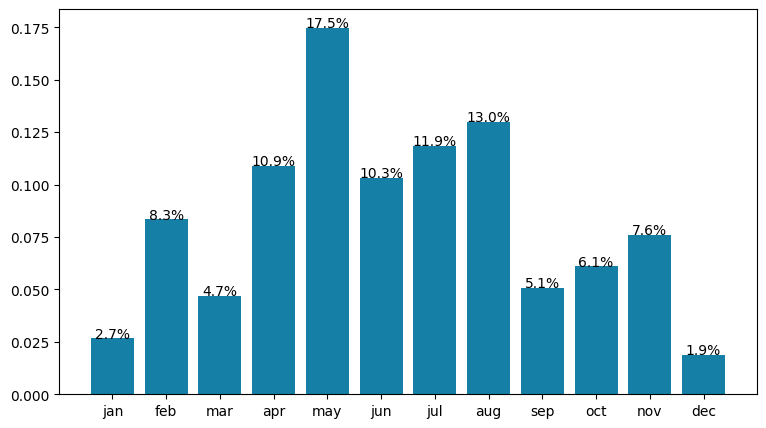

In [ ]:
plt.figure(figsize=(9,5))
plt.bar(
    contrataciones_mes['month'],
    contrataciones_mes['tasa_mes'],
    color="#157fa6"
)


for i, v in enumerate(contrataciones_mes['tasa_mes']):
    plt.text(i, v + 0.0001, f"{v:.1%}", ha='center', fontsize=10)



plt.show()


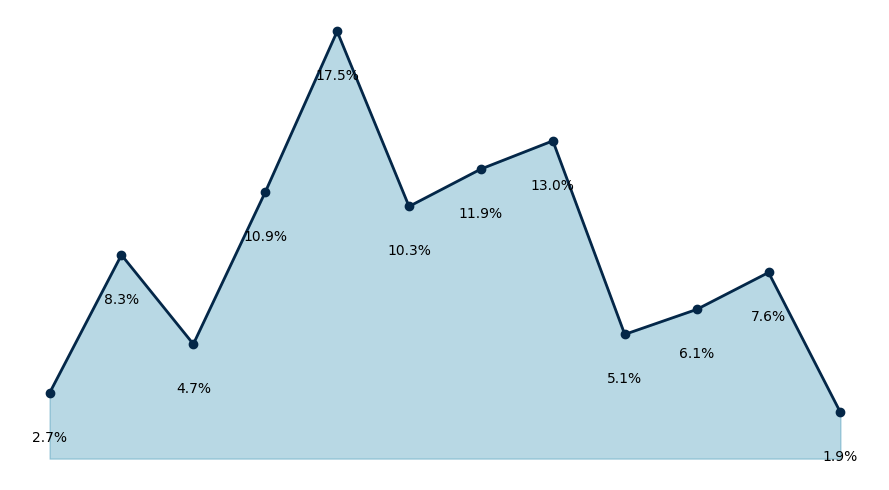

In [ ]:
plt.figure(figsize=(9,5))

plt.fill_between(
    contrataciones_mes['month'],
    contrataciones_mes['tasa_mes'],
    color="#157fa6",
    alpha=0.3
)


plt.plot(
    contrataciones_mes['month'],
    contrataciones_mes['tasa_mes'],
    marker='o',
    color="#042748",
    linewidth=2
)


for i, v in enumerate(contrataciones_mes['tasa_mes']):
    plt.text(i, v - 0.02, f"{v:.1%}", ha='center', fontsize=10, color="black")


ax = plt.gca()
ax.axis('off')

plt.tight_layout()
plt.show()



In [ ]:

resumen_mes = (
    df_BANK_marketing
    .groupby(['month', 'deposit'])
    .size()
    .reset_index(name='n_clientes')
)


orden_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

resumen_mes['month'] = pd.Categorical(
    resumen_mes['month'],
    categories=orden_meses,
    ordered=True
)

resumen_mes = resumen_mes.sort_values(['month', 'deposit'])

print(resumen_mes)


   month deposit  n_clientes
8    jan      no         202
9    jan     yes         142
6    feb      no         335
7    feb     yes         441
14   mar      no          28
15   mar     yes         248
0    apr      no         346
1    apr     yes         577
16   may      no        1899
17   may     yes         925
12   jun      no         676
13   jun     yes         546
10   jul      no         887
11   jul     yes         627
2    aug      no         831
3    aug     yes         688
22   sep      no          50
23   sep     yes         269
20   oct      no          69
21   oct     yes         323
18   nov      no         540
19   nov     yes         403
4    dec      no          10
5    dec     yes         100


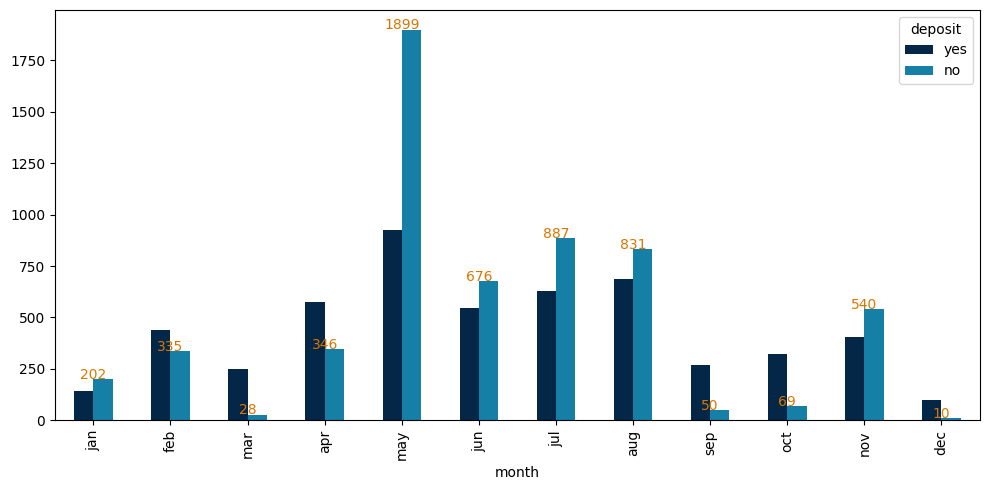

In [ ]:


resumen_pivot = resumen_mes.pivot(index='month', columns='deposit', values='n_clientes').fillna(0)


colores = ["#042748", "#157fa6"]


resumen_pivot[['yes', 'no']].plot(
    kind='bar',
    figsize=(10,5),
    color=colores
)


for i, month in enumerate(resumen_pivot.index):
    yes_val = resumen_pivot.loc[month, 'yes']
    no_val = resumen_pivot.loc[month, 'no']

    plt.text(i, no_val + 0.5, str(int(no_val)), ha='center', fontsize=10, color="#d97600")

plt.tight_layout()
plt.show()

